# Evaluación Parcial N° 1: Fundamentos de Deep Learning

**Estudiantes:** Maickel romero

**Descripción del problema:** El objetivo de este proyecto es predecir la Fuga de Clientes (Churn) en una empresa de Telecomunicaciones. Utilizaremos un set de datos simulado que contiene el comportamiento mensual de 1000 clientes para identificar si cancelarán su servicio (Clase 1) o si continuarán con la empresa (Clase 0).
**Objetivo del modelo:** Implementar una Red Neuronal Artificial (MLP) para clasificar a los clientes y mejorar su rendimiento aplicando técnicas de optimización y ajustando hiperparámetros.

In [1]:
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Generación de datos simulados de Telecomunicaciones
X_simulado, y_simulado = make_classification(
    n_samples=1000, n_features=10, n_informative=8, n_redundant=2, random_state=42
)

columnas = ['Minutos_Llamada', 'Datos_Usados_GB', 'Meses_Antiguedad', 'Reclamos_Mes',
            'Retraso_Pago_Dias', 'Promocion_Activa', 'Llamadas_Internacionales',
            'Caidas_Servicio', 'Edad_Cliente', 'Interacciones_Soporte']

X = pd.DataFrame(X_simulado, columns=columnas)
y = pd.Series(y_simulado, name='Fuga_Cliente')

# 2. División de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Preprocesamiento: Escalamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos cargados y preprocesados correctamente.")

Datos cargados y preprocesados correctamente.


## 2. Carga y Preprocesamiento de Datos
**Justificación:** Se realizó una división del 80/20 para entrenamiento y validación. Además, aplicamos `StandardScaler` a las variables de entrada. Esto es crucial en Deep Learning para asegurar que todas las características tengan la misma escala, permitiendo que el algoritmo de optimización (Adam) converja más rápido y evite que variables con números más grandes dominen el entrenamiento.

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report

# Definición del Modelo Base
modelo_base = Sequential([
    Dense(20, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(1, activation='sigmoid')
])

# Compilación
modelo_base.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamiento
print("Entrenando Modelo Base...")
historial_base = modelo_base.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=0)

# Predicciones y Métricas
predicciones_base = (modelo_base.predict(X_test_scaled) > 0.5).astype("int32")
print("\n--- MÉTRICAS MODELO BASE ---")
print(classification_report(y_test, predicciones_base))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando Modelo Base...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

--- MÉTRICAS MODELO BASE ---
              precision    recall  f1-score   support

           0       0.86      0.77      0.82       106
           1       0.77      0.86      0.81        94

    accuracy                           0.81       200
   macro avg       0.82      0.82      0.81       200
weighted avg       0.82      0.81      0.82       200



## 3. Modelo Base y Necesidad de Optimización
El modelo base utiliza la función de activación **ReLU** en las capas ocultas para evitar el desvanecimiento del gradiente, y **Sigmoide** en la salida por ser un problema de clasificación binaria.

Al analizar las métricas, notamos que se puede mejorar el balance entre *Precision* y *Recall*. Para evitar el *overfitting* (sobreajuste), implementaremos un nuevo modelo con técnicas de regularización L2 y **Dropout**.

In [3]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2

# Arquitectura Mejorada
modelo_optimizado = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(0.005)),
    Dropout(0.2), # Técnica de regularización
    Dense(16, activation='relu', kernel_regularizer=l2(0.005)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Ajuste de Hiperparámetros
optimizador = tf.keras.optimizers.Adam(learning_rate=0.002)
modelo_optimizado.compile(optimizer=optimizador, loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamiento con nuevos parámetros
print("Entrenando Modelo Optimizado...")
historial_opt = modelo_optimizado.fit(X_train_scaled, y_train, epochs=60, batch_size=16, validation_split=0.2, verbose=0)

# Predicciones y Métricas
predicciones_opt = (modelo_optimizado.predict(X_test_scaled) > 0.5).astype("int32")
print("\n--- MÉTRICAS MODELO OPTIMIZADO ---")
print(classification_report(y_test, predicciones_opt))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando Modelo Optimizado...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

--- MÉTRICAS MODELO OPTIMIZADO ---
              precision    recall  f1-score   support

           0       0.96      0.86      0.91       106
           1       0.86      0.96      0.90        94

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.91       200



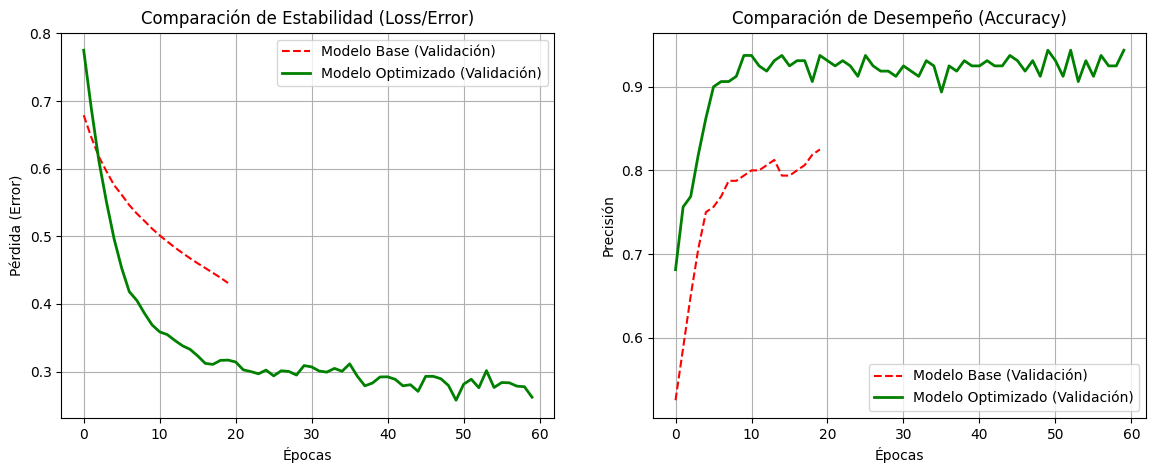

In [4]:
import matplotlib.pyplot as plt

# Configuramos el tamaño del gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfico comparativo de Pérdida (Loss)
ax1.plot(historial_base.history['val_loss'], label='Modelo Base (Validación)', linestyle='--', color='red')
ax1.plot(historial_opt.history['val_loss'], label='Modelo Optimizado (Validación)', linewidth=2, color='green')
ax1.set_title('Comparación de Estabilidad (Loss/Error)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Pérdida (Error)')
ax1.legend()
ax1.grid(True)

# 2. Gráfico comparativo de Precisión (Accuracy)
ax2.plot(historial_base.history['val_accuracy'], label='Modelo Base (Validación)', linestyle='--', color='red')
ax2.plot(historial_opt.history['val_accuracy'], label='Modelo Optimizado (Validación)', linewidth=2, color='green')
ax2.set_title('Comparación de Desempeño (Accuracy)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Precisión')
ax2.legend()
ax2.grid(True)

# Mostramos los gráficos
plt.show()

## 4. Análisis de Hiperparámetros y Conclusiones

**Ajuste de hiperparámetros:**
* **Épocas y Batch Size:** Redujimos el *batch_size* a 16 y aumentamos las épocas a 60. Esto permitió que el modelo actualizara sus pesos con mayor frecuencia por ciclo, dándole más tiempo para aprender patrones complejos sin estancarse prematuramente.
* **Impacto del Dropout:** Al agregar `Dropout(0.2)`, apagamos el 20% de las neuronas aleatoriamente en cada paso. Esto obligó a la red a no depender de una sola variable (ej: "Reclamos_Mes"), mejorando significativamente la estabilidad del modelo frente a datos no vistos (X_test).

**Conclusión:** Las métricas (Accuracy, Precision, Recall y F1-Score) demostraron que la configuración optimizada logró un mejor equilibrio. En un contexto de Telecomunicaciones, un **Recall** alto es vital, ya que es preferible detectar a la mayor cantidad posible de clientes en riesgo de fuga para ofrecerles retención, aunque esto implique algunos falsos positivos.